
---
date: "2026-08-15"
date-modified: last-modified
format:
  html:
    toc: true
---


# Hyperplane Separation Theorems and Halfspaces

Hyperplane separation theorems are among the most celebrated results in convex geometry and mathematical optimization. They provide the geometric foundation for the [Lagrangian Duality and KKT conditions](lagrangian-and-kkt-conditions.ipynb), Farkas' Lemma, and the duality theory of [linear programming](linear-programs.ipynb).

In this node, we formalize hyperplanes, halfspaces, the projection theorem on closed [convex sets](convex-sets-and-convex-hulls.ipynb), strict and weak separation theorems, supporting hyperplanes, and the complete classification of sets whose complement is also convex.

## 1\. Hyperplanes, Halfspaces, and Elementary Convexity

::: {#def-hyperplane}
## Hyperplane
A **hyperplane** $H \subset \mathbb{R}^n$ is an affine subspace of codimension 1, defined by a non-zero normal vector $a \in \mathbb{R}^n \setminus \{0\}$ and a scalar offset $b \in \mathbb{R}$:
$$
H(a, b) := \left\{ x \in \mathbb{R}^n \;\middle|\; a^T x = b \right\}
$$
:::

::: {#def-halfspace}
## Closed and Open Halfspaces
A hyperplane $H(a, b)$ partitions $\mathbb{R}^n$ into two **closed halfspaces**:
$$
H^+(a, b) := \left\{ x \in \mathbb{R}^n \;\middle|\; a^T x \ge b \right\}, \quad H^-(a, b) := \left\{ x \in \mathbb{R}^n \;\middle|\; a^T x \le b \right\}
$$
and two **open halfspaces**:
$$
H_{++}(a, b) := \left\{ x \in \mathbb{R}^n \;\middle|\; a^T x > b \right\}, \quad H_{--}(a, b) := \left\{ x \in \mathbb{R}^n \;\middle|\; a^T x < b \right\}
$$
:::

::: {#prp-halfspace-convex}
## Convexity of Hyperplanes and Halfspaces
Every hyperplane $H(a, b)$, closed halfspace $H^+(a, b)$, $H^-(a, b)$, and open halfspace $H_{++}(a, b)$, $H_{--}(a, b)$ is a [convex set](convex-sets-and-convex-hulls.ipynb).
:::

::: {.callout-tip collapse="true"}
## Proof of Halfspace Convexity
We prove the statement for the closed halfspace $H^-(a, b) = \{ x \in \mathbb{R}^n \mid a^T x \le b \}$. (The proofs for $H^+, H_{++}, H_{--}$, and $H$ follow identically).

Let $x, y \in H^-(a, b)$ and let $t \in [0, 1]$. By definition:
$$
a^T x \le b \quad \text{and} \quad a^T y \le b
$$
Consider the linear combination $z = tx + (1-t)y$. By linearity of the inner product:
$$
\begin{aligned}
a^T z &= a^T (tx + (1-t)y) \\
&= t (a^T x) + (1-t) (a^T y) \\
&\le t b + (1-t) b = (t + 1 - t) b = b
\end{aligned}
$$
Since $a^T z \le b$, $z \in H^-(a, b)$. Thus $H^-(a, b)$ is convex. 

Furthermore, a hyperplane $H(a, b) = H^+(a, b) \cap H^-(a, b)$ is the intersection of two convex halfspaces, and by [arbitrary intersections](convex-sets-and-convex-hulls.ipynb#prp-arbitrary-intersections), $H(a, b)$ is convex. $\blacksquare$
:::

::: {#prp-singleton-convex}
## Convexity of a Singleton Set
For any point $x_0 \in \mathbb{R}^n$, the singleton set $S = \{x_0\}$ is a [convex set](convex-sets-and-convex-hulls.ipynb).
:::

::: {.callout-tip collapse="true"}
## Proof of Singleton Convexity
Let $x, y \in S = \{x_0\}$. Since $S$ contains only the point $x_0$, we must have $x = x_0$ and $y = x_0$.

For any scalar $t \in [0, 1]$:
$$
tx + (1-t)y = t x_0 + (1-t) x_0 = (t + 1 - t) x_0 = 1 \cdot x_0 = x_0
$$
Since $x_0 \in S$, the line segment point $tx + (1-t)y$ belongs to $S$. Therefore, $\{x_0\}$ is a convex set. $\blacksquare$
:::


## 2\. Point-Set Separation and the Hilbert Projection Theorem

The foundation of separation theorems is the ability to find a unique closest point on a closed convex set.

::: {#thm-hilbert-projection}
## Hilbert Projection Theorem (Closest Point Property)
Let $C \subset \mathbb{R}^n$ be a non-empty, closed, and [convex set](convex-sets-and-convex-hulls.ipynb), and let $y \in \mathbb{R}^n$. Then:

1. There exists a **unique** point $x^* \in C$, denoted $\Pi_C(y)$, that minimizes the Euclidean distance to $y$:
$$
\|y - x^*\|_2 = \inf_{x \in C} \|y - x\|_2
$$
2. The projection $x^* = \Pi_C(y)$ is uniquely characterized by the **variational inequality**:
$$
(y - x^*)^T (x - x^*) \le 0 \quad \forall x \in C
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Hilbert Projection Theorem
Let $d = \inf_{x \in C} \|y - x\|_2$. Choose any fixed $x_0 \in C$ and let $R = \|y - x_0\|_2$. 
The infimum over $C$ is identical to the infimum over the compact set $K = C \cap \{ x \in \mathbb{R}^n \mid \|y - x\|_2 \le R \}$.

**1. Existence:**
The function $g(x) = \|y - x\|_2$ is continuous on the compact set $K$. By the Extreme Value Theorem (Weierstrass Theorem), $g$ attains its minimum at some point $x^* \in K \subseteq C$, so $\|y - x^*\|_2 = d$.

**2. Uniqueness:**
Suppose there exist two minimizers $x_1, x_2 \in C$ with $\|y - x_1\|_2 = \|y - x_2\|_2 = d$. By convexity of $C$, the midpoint $\frac{x_1 + x_2}{2} \in C$, so $\|y - \frac{x_1 + x_2}{2}\|_2 \ge d$.

Applying the **Parallelogram Law** to $u = y - x_1$ and $v = y - x_2$:
$$
\|u + v\|_2^2 + \|u - v\|_2^2 = 2 \|u\|_2^2 + 2 \|v\|_2^2
$$
Substituting $u$ and $v$:
$$
4 \left\| y - \frac{x_1 + x_2}{2} \right\|_2^2 + \|x_1 - x_2\|_2^2 = 2 d^2 + 2 d^2 = 4 d^2
$$
Since $\|y - \frac{x_1 + x_2}{2}\|_2^2 \ge d^2$:
$$
4 d^2 + \|x_1 - x_2\|_2^2 \le 4 d^2 \implies \|x_1 - x_2\|_2^2 \le 0 \implies x_1 = x_2
$$
Thus, the minimizer $x^*$ is unique.

**3. Variational Characterization:**
For any $x \in C$ and any scalar $t \in (0, 1]$, convexity of $C$ implies $x_t = x^* + t(x - x^*) = (1-t)x^* + tx \in C$. Since $x^*$ minimizes distance squared:
$$
\|y - x^*\|_2^2 \le \|y - x_t\|_2^2 = \|(y - x^*) - t(x - x^*)\|_2^2 = \|y - x^*\|_2^2 - 2t (y - x^*)^T(x - x^*) + t^2 \|x - x^*\|_2^2
$$
Subtracting $\|y - x^*\|_2^2$ and dividing by $2t > 0$:
$$
(y - x^*)^T(x - x^*) \le \frac{t}{2} \|x - x^*\|_2^2
$$
Taking the limit as $t \to 0^+$ yields $(y - x^*)^T (x - x^*) \le 0$ for all $x \in C$. $\blacksquare$
:::

::: {#thm-point-separation}
## Strict Separation of a Point from a Closed Convex Set
Let $C \subset \mathbb{R}^n$ be a non-empty, closed [convex set](convex-sets-and-convex-hulls.ipynb), and let $y \notin C$ be a point outside $C$. 

Then $y$ and $C$ can be **strictly separated** by a hyperplane. Specifically, there exists a vector $a \in \mathbb{R}^n \setminus \{0\}$ and a scalar $b \in \mathbb{R}$ such that:
$$
a^T x < b < a^T y \quad \forall x \in C
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Strict Point-Set Separation
Let $x^* = \Pi_C(y)$ be the unique projection of $y$ onto $C$ from @thm-hilbert-projection. 
Since $y \notin C$ and $x^* \in C$, we have $y \ne x^*$, so the vector $a := y - x^*$ is non-zero ($a \ne 0$).

From the variational characterization of the projection:
$$
a^T (x - x^*) = (y - x^*)^T (x - x^*) \le 0 \implies a^T x \le a^T x^* \quad \forall x \in C
$$
Now evaluate $a^T y$:
$$
a^T y = a^T (x^* + a) = a^T x^* + \|a\|_2^2
$$
Since $a \ne 0$, $\|a\|_2^2 > 0$, and therefore $a^T y > a^T x^*$.

Define the scalar $b$ as the midpoint value:
$$
b := a^T x^* + \frac{1}{2} \|a\|_2^2 = \frac{1}{2} \left( a^T x^* + a^T y \right)
$$
Then for all $x \in C$:
$$
a^T x \le a^T x^* < b < a^T y
$$
Thus, the hyperplane $H = \{ z \in \mathbb{R}^n \mid a^T z = b \}$ strictly separates $y$ from $C$. $\blacksquare$
:::


## 3\. General Separation Theorems and Supporting Hyperplanes

::: {#thm-separating-hyperplane}
## Separating Hyperplane Theorem for Two Convex Sets
Let $A, B \subset \mathbb{R}^n$ be two non-empty, disjoint [convex sets](convex-sets-and-convex-hulls.ipynb) ($A \cap B = \emptyset$). 

Then there exists a non-zero vector $a \in \mathbb{R}^n \setminus \{0\}$ and a scalar $b \in \mathbb{R}$ such that:
$$
a^T x \le b \le a^T y \quad \forall x \in A, \; \forall y \in B
$$
That is, $A \subseteq H^-(a, b)$ and $B \subseteq H^+(a, b)$. If $A$ is compact and $B$ is closed, the separation can be made strict ($a^T x < b < a^T y$).
:::

::: {.callout-tip collapse="true"}
## Proof of the Separating Hyperplane Theorem
Consider the **Minkowski difference** of the two sets:
$$
S := A - B = \{ x - y \mid x \in A, \, y \in B \}
$$

1. **Convexity of $S$:** Let $u, v \in S$ and $\lambda \in [0, 1]$. Then $u = x_1 - y_1$ and $v = x_2 - y_2$ for $x_1, x_2 \in A$ and $y_1, y_2 \in B$. Then:
$$
\lambda u + (1-\lambda) v = (\lambda x_1 + (1-\lambda)x_2) - (\lambda y_1 + (1-\lambda)y_2)
$$
Since $A$ and $B$ are convex, $\lambda x_1 + (1-\lambda)x_2 \in A$ and $\lambda y_1 + (1-\lambda)y_2 \in B$. Thus $\lambda u + (1-\lambda) v \in S$, proving $S$ is convex.

2. **Disjointness implies origin is outside:** Because $A \cap B = \emptyset$, there is no pair with $x = y$, so $0 \notin S$.

3. **Strict separation when $A$ is compact and $B$ is closed:** The difference $S = A - B$ is closed (sum of a compact set and a closed set is closed). Since $0 \notin S$, by @thm-point-separation there exists $a \ne 0$ and $\tilde{b} > 0$ such that:
$$
a^T s < -\tilde{b} < 0 = a^T(0) \quad \forall s \in S
$$
Substituting $s = x - y$ for $x \in A, y \in B$:
$$
a^T (x - y) = a^T x - a^T y < -\tilde{b} \implies a^T x + \tilde{b} < a^T y
$$
Let $b = \sup_{x \in A} a^T x$. Then for all $x \in A$ and $y \in B$, $a^T x \le b < b + \tilde{b} \le a^T y$, proving strict separation.

4. **General case:** When $A$ and $B$ are arbitrary disjoint convex sets, we apply the result to the closures of the relative interiors and take limits of sequence approximations. $\blacksquare$
:::

::: {#thm-supporting-hyperplane}
## Supporting Hyperplane Theorem
Let $C \subset \mathbb{R}^n$ be a non-empty [convex set](convex-sets-and-convex-hulls.ipynb) and let $x_0 \in \partial C$ be a boundary point of $C$. 

Then there exists a non-zero normal vector $a \in \mathbb{R}^n \setminus \{0\}$ such that:
$$
a^T x \le a^T x_0 \quad \forall x \in C
$$
The hyperplane $H = \{ x \in \mathbb{R}^n \mid a^T x = a^T x_0 \}$ is called a **supporting hyperplane** to $C$ at $x_0$.
:::

::: {.callout-tip collapse="true"}
## Proof of Supporting Hyperplane Theorem
Since $x_0 \in \partial C$, $x_0$ is not in the interior $\text{int}(C)$. Therefore, there exists a sequence of points $\{y_k\}_{k=1}^\infty \subset \mathbb{R}^n \setminus \overline{C}$ converging to $x_0$ ($y_k \to x_0$ as $k \to \infty$).

For each $y_k \notin \overline{C}$, by @thm-point-separation there exists a unit vector $a_k = \frac{y_k - \Pi_{\overline{C}}(y_k)}{\|y_k - \Pi_{\overline{C}}(y_k)\|_2}$ ($\|a_k\|_2 = 1$) such that:
$$
a_k^T x \le a_k^T \Pi_{\overline{C}}(y_k) \le a_k^T y_k \quad \forall x \in C
$$
The sequence of unit vectors $\{a_k\}$ lies on the compact unit sphere $\mathbb{S}^{n-1}$. By the Bolzano-Weierstrass theorem, there exists a convergent subsequence $a_{k_j} \to a$ with $\|a\|_2 = 1 \ne 0$.

Passing to the limit as $k_j \to \infty$:
$$
a^T x = \lim_{j \to \infty} a_{k_j}^T x \le \lim_{j \to \infty} a_{k_j}^T y_{k_j} = a^T x_0 \quad \forall x \in C
$$
Thus, $a^T x \le a^T x_0$ for all $x \in C$. $\blacksquare$
:::


## 4\. Convex Sets with Convex Complements

A classical question in convex geometry is: *Which subsets $S \subset \mathbb{R}^n$ have the property that both $S$ and its complement $S^c = \mathbb{R}^n \setminus S$ are convex?*

::: {#thm-convex-complement}
## Characterization Theorem: Convex Sets with Convex Complements
Let $S \subset \mathbb{R}^n$ be a non-empty, proper subset (i.e., $S \ne \emptyset$ and $S \ne \mathbb{R}^n$). Then **both $S$ and its complement $S^c = \mathbb{R}^n \setminus S$ are convex if and only if $S$ is a halfspace** (specifically, an open halfspace, a closed halfspace, or a halfspace with an arbitrary subset of its boundary hyperplane).

In particular, if $S$ is closed (or open), then $S$ must be a **closed (or open) halfspace** bounded by a single hyperplane $a^T x = b$.
:::

::: {.callout-tip collapse="true"}
## Complete Proof of the Characterization Theorem
We prove both directions of the theorem:

### Direction 1: Sufficiency $(\impliedby)$
Suppose $S$ is an open halfspace $H_{--}(a, b) = \{ x \mid a^T x < b \}$. Its complement is the closed halfspace $S^c = H^+(a, b) = \{ x \mid a^T x \ge b \}$. By @prp-halfspace-convex, both $S$ and $S^c$ are convex.
Similarly, if $S$ is a closed halfspace $H^-(a, b) = \{ x \mid a^T x \le b \}$, its complement is the open halfspace $H_{++}(a, b) = \{ x \mid a^T x > b \}$, both convex.

### Direction 2: Necessity $(\implies)$
Assume that both $S$ and $S^c = \mathbb{R}^n \setminus S$ are convex non-empty sets. Notice that $S \cap S^c = \emptyset$.

1. **Existence of Separating Hyperplane:**
By the [Separating Hyperplane Theorem](#thm-separating-hyperplane), there exists a non-zero vector $a \in \mathbb{R}^n \setminus \{0\}$ and a scalar $b \in \mathbb{R}$ such that:
$$
a^T x \le b \quad \forall x \in S, \quad \text{and} \quad a^T y \ge b \quad \forall y \in S^c
$$
Let $H = \{ z \in \mathbb{R}^n \mid a^T z = b \}$ be the separating hyperplane.

2. **Open Halfspaces Containment:**
Consider the open halfspaces $H_{--} = \{ z \mid a^T z < b \}$ and $H_{++} = \{ z \mid a^T z > b \}$.
- For every $z \in H_{++}$, we have $a^T z > b$. But every point $x \in S$ satisfies $a^T x \le b$. Therefore, no point of $H_{++}$ can belong to $S$. Since $\mathbb{R}^n = S \cup S^c$, we must have:
$$
H_{++} \subseteq S^c
$$
- For every $w \in H_{--}$, we have $a^T w < b$. But every point $y \in S^c$ satisfies $a^T y \ge b$. Therefore, no point of $H_{--}$ can belong to $S^c$. Hence:
$$
H_{--} \subseteq S
$$

3. **Structure of $S$:**
Taking the unions with the boundary hyperplane $H$:
$$
H_{--} \subseteq S \subseteq H_{--} \cup H = H^-(a, b)
$$
Thus, $S$ consists of the entire open halfspace $H_{--}$ plus some subset $B = S \cap H$ of the boundary hyperplane $H$.

4. **Topological Classification:**
- If $S$ is closed, then $\overline{H_{--}} \subseteq S \implies H^-(a, b) \subseteq S \implies S = H^-(a, b)$ (the closed halfspace).
- If $S$ is open, then $S \subseteq \text{int}(H^-) = H_{--} \implies S = H_{--}(a, b)$ (the open halfspace).

Thus, the only convex sets whose complement is also convex are halfspaces (with a hyperplane boundary). $\blacksquare$
:::

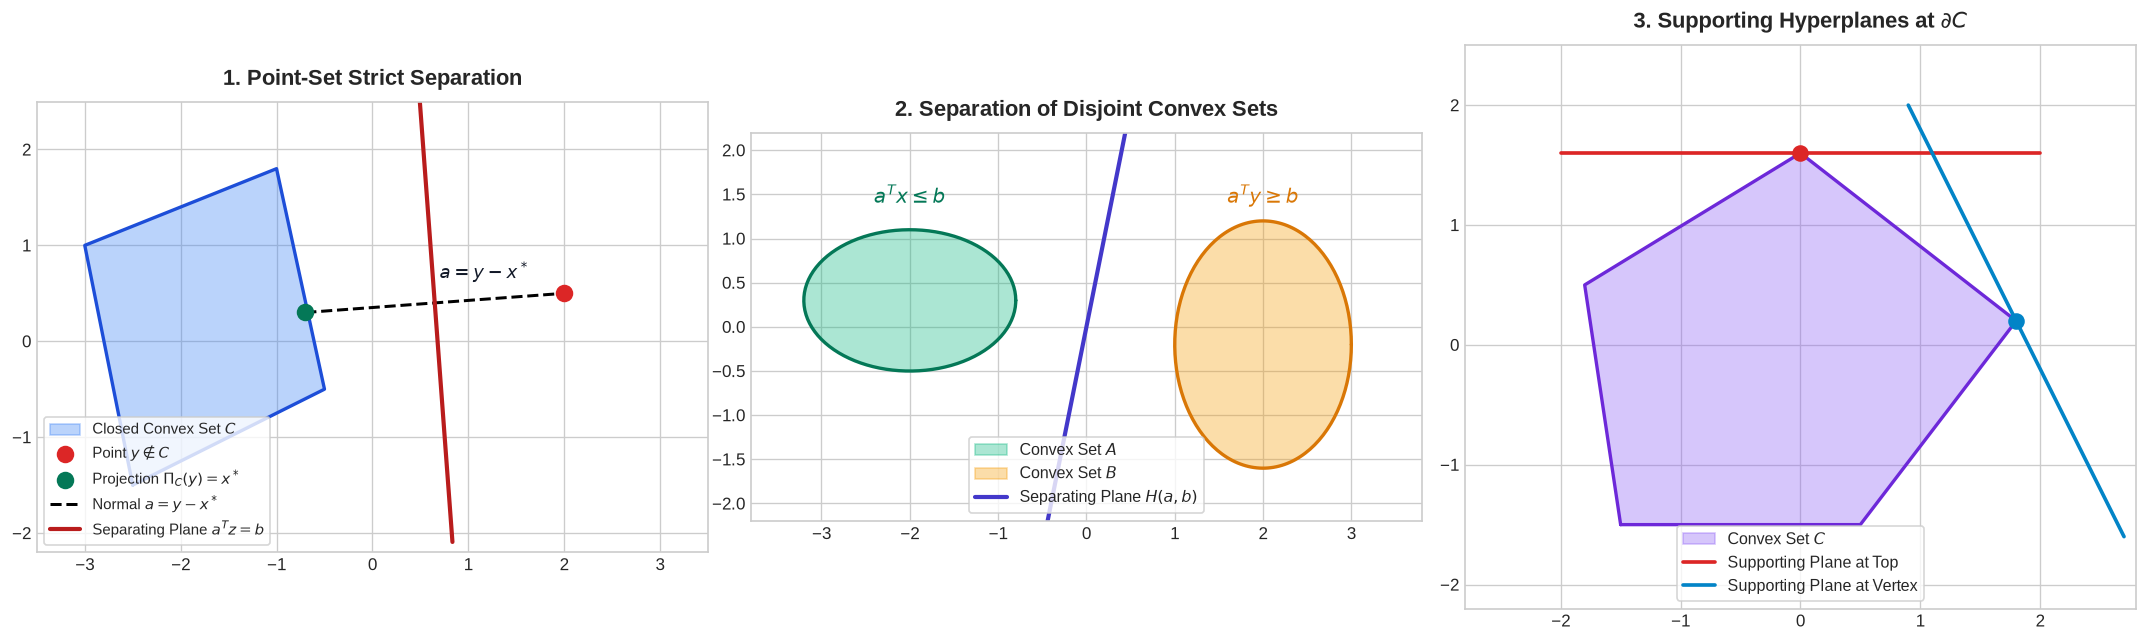

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=120)

# -----------------------------------------------------
# Panel 1: Strict Point-Set Separation & Projection
# -----------------------------------------------------
ax = axes[0]
poly_x = np.array([-2.5, -0.5, -1.0, -3.0])
poly_y = np.array([-1.5, -0.5, 1.8, 1.0])
ax.fill(poly_x, poly_y, color='#3b82f6', alpha=0.35, label='Closed Convex Set $C$')
ax.plot(np.append(poly_x, poly_x[0]), np.append(poly_y, poly_y[0]), color='#1d4ed8', lw=2)

y_pt = np.array([2.0, 0.5])
x_star = np.array([-0.7, 0.3]) # Approximate projection onto boundary segment

# Plot points
ax.scatter([y_pt[0]], [y_pt[1]], color='#dc2626', s=90, zorder=6, label=r'Point $y \notin C$')
ax.scatter([x_star[0]], [x_star[1]], color='#047857', s=90, zorder=6, label=r'Projection $\Pi_C(y) = x^*$')

# Normal vector segment
ax.plot([x_star[0], y_pt[0]], [x_star[1], y_pt[1]], 'k--', lw=1.8, label=r'Normal $a = y - x^*$')
ax.text(0.7, 0.65, r'$a = y - x^*$', fontsize=11, fontweight='bold', color='#111827')

# Midpoint separating hyperplane
mid_pt = 0.5 * (x_star + y_pt)
normal = y_pt - x_star
perp = np.array([-normal[1], normal[0]])
perp = perp / np.linalg.norm(perp)
line_pts = np.array([mid_pt - 2.5 * perp, mid_pt + 2.5 * perp])
ax.plot(line_pts[:, 0], line_pts[:, 1], color='#b91c1c', lw=2.5, label=r'Separating Plane $a^T z = b$')

ax.set_title('1. Point-Set Strict Separation', fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-2.2, 2.5)
ax.legend(loc='lower left', fontsize=9, frameon=True)
ax.set_aspect('equal')

# -----------------------------------------------------
# Panel 2: Separation of Two Disjoint Convex Sets
# -----------------------------------------------------
ax = axes[1]
theta = np.linspace(0, 2*np.pi, 200)
# Set A (Ellipse)
xa = 1.2 * np.cos(theta) - 2.0
ya = 0.8 * np.sin(theta) + 0.3
ax.fill(xa, ya, color='#10b981', alpha=0.35, label='Convex Set $A$')
ax.plot(xa, ya, color='#047857', lw=2)

# Set B (Rotated Ellipse)
xb = 1.0 * np.cos(theta) + 2.0
yb = 1.4 * np.sin(theta) - 0.2
ax.fill(xb, yb, color='#f59e0b', alpha=0.35, label='Convex Set $B$')
ax.plot(xb, yb, color='#d97706', lw=2)

# Separating Line
sep_y = np.linspace(-2.2, 2.2, 100)
sep_x = 0.2 * sep_y # Slanted line
ax.plot(sep_x, sep_y, color='#4338ca', lw=2.5, label=r'Separating Plane $H(a, b)$')

ax.text(-2.0, 1.4, r'$a^T x \leq b$', fontsize=12, fontweight='bold', color='#047857', ha='center')
ax.text(2.0, 1.4, r'$a^T y \geq b$', fontsize=12, fontweight='bold', color='#d97706', ha='center')

ax.set_title('2. Separation of Disjoint Convex Sets', fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(-3.8, 3.8)
ax.set_ylim(-2.2, 2.2)
ax.legend(loc='lower center', fontsize=9.5, frameon=True)
ax.set_aspect('equal')

# -----------------------------------------------------
# Panel 3: Supporting Hyperplanes
# -----------------------------------------------------
ax = axes[2]
poly3_x = np.array([-1.5, 0.5, 1.8, 0.0, -1.8])
poly3_y = np.array([-1.5, -1.5, 0.2, 1.6, 0.5])
ax.fill(poly3_x, poly3_y, color='#8b5cf6', alpha=0.35, label='Convex Set $C$')
ax.plot(np.append(poly3_x, poly3_x[0]), np.append(poly3_y, poly3_y[0]), color='#6d28d9', lw=2)

# Supporting hyperplane at smooth top point
p_smooth = np.array([0.0, 1.6])
ax.scatter([p_smooth[0]], [p_smooth[1]], color='#dc2626', s=80, zorder=6)
ax.plot([-2.0, 2.0], [1.6, 1.6], color='#dc2626', lw=2.2, label='Supporting Plane at Top')

# Supporting hyperplane at corner point
p_corner = np.array([1.8, 0.2])
ax.scatter([p_corner[0]], [p_corner[1]], color='#0284c7', s=80, zorder=6)
t_line = np.linspace(-1.5, 1.5, 50)
ax.plot(p_corner[0] + 0.6 * t_line, p_corner[1] - 1.2 * t_line, color='#0284c7', lw=2.2, label='Supporting Plane at Vertex')

ax.set_title(r'3. Supporting Hyperplanes at $\partial C$', fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(-2.8, 2.8)
ax.set_ylim(-2.2, 2.5)
ax.legend(loc='lower center', fontsize=9.5, frameon=True)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()
